# Autoencoder for Image Denoising (MNIST)

**Week-6 Assessment — Deep Learning (AE & GAN)**

**Goal:** Build a deep learning model that removes noise from images using a
**convolutional denoising autoencoder**, trained on the MNIST handwritten-digit
dataset.

### What is a denoising autoencoder?
An autoencoder is a neural network that learns to reconstruct its input. It has
two parts:

- **Encoder** — compresses the image into a small *latent* (bottleneck) representation.
- **Decoder** — reconstructs the image back from that representation.

For *denoising*, we feed the network a **noisy** image as input but ask it to
reconstruct the **clean** original. To do this well, the network is forced to
learn the underlying structure of a digit (strokes, curves) and ignore the
random noise. At inference time it can therefore clean up noisy images it has
never seen.

```
clean image  --(add noise)-->  noisy image  --[ Encoder -> latent -> Decoder ]-->  reconstructed (clean) image
                                                         (the network)              loss compared against clean image
```

In [1]:
# ── Imports & device setup ────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use Apple-Silicon GPU (MPS) / CUDA if available, else CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Using device:", device)

PyTorch: 2.11.0
Using device: mps


## 1. Load the MNIST data

The Kaggle dataset stores MNIST as PNG images organised in folders by digit:

```
data/mnist_png/training/0/ ... 9/      (60,000 images)
data/mnist_png/testing/0/  ... 9/      (10,000 images)
```

`torchvision.datasets.ImageFolder` reads that folder layout automatically. We
convert each image to a single-channel `[1, 28, 28]` tensor with pixel values
scaled to **[0, 1]**.

For speed we read every image into memory **once** and stack it into a tensor —
this avoids decoding PNGs from disk on every epoch.

In [2]:
DATA_DIR = "data/mnist_png"

# Grayscale + scale pixels to [0,1]
to_tensor = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),                       # -> float tensor in [0,1]
])

train_folder = datasets.ImageFolder(os.path.join(DATA_DIR, "training"), transform=to_tensor)
test_folder  = datasets.ImageFolder(os.path.join(DATA_DIR, "testing"),  transform=to_tensor)

def folder_to_tensor(folder):
    # Stack every image in an ImageFolder into one [N, 1, 28, 28] tensor
    imgs = torch.stack([img for img, _ in folder])
    return imgs

print("Loading images into memory (this takes a moment the first time)...")
x_train = folder_to_tensor(train_folder)
x_test  = folder_to_tensor(test_folder)
print("Train tensor:", x_train.shape, "| Test tensor:", x_test.shape)
print("Pixel range:", x_train.min().item(), "to", x_train.max().item())

Loading images into memory (this takes a moment the first time)...


Train tensor: torch.Size([60000, 1, 28, 28]) | Test tensor: torch.Size([10000, 1, 28, 28])
Pixel range: 0.0 to 1.0


## 2. Add noise

We corrupt the clean images with **Gaussian noise** and clip the result back to
the valid `[0, 1]` range. `NOISE_FACTOR` controls how strong the noise is.

The clean images are the *targets*; the noisy images are the *inputs*.

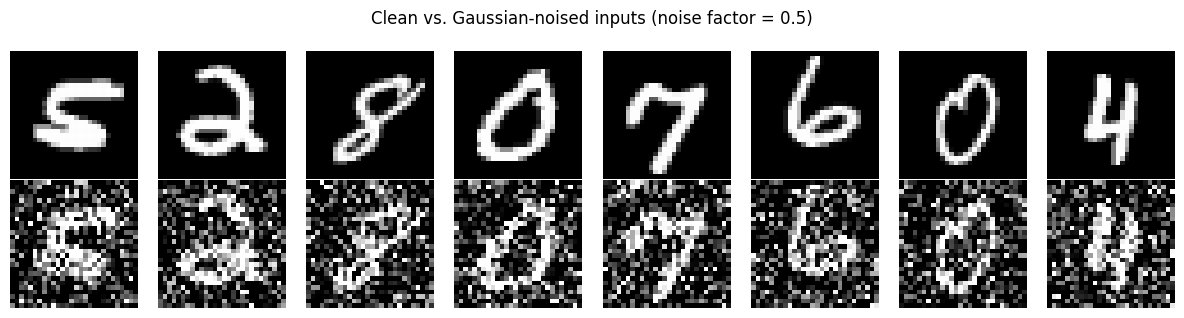

In [3]:
NOISE_FACTOR = 0.5

def add_noise(imgs, factor=NOISE_FACTOR):
    # Add Gaussian noise and clamp back to the valid [0, 1] range
    noisy = imgs + factor * torch.randn_like(imgs)
    return torch.clamp(noisy, 0.0, 1.0)

# Build noisy versions of the test set once, for consistent visual comparison
x_test_noisy = add_noise(x_test)

# Pick a spread of different digits to visualise (the test set is sorted by class)
sample_idx = torch.randperm(len(x_test))[:10]

# Quick look: clean (top) vs noisy (bottom)
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    j = sample_idx[i]
    axes[0, i].imshow(x_test[j, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(x_test_noisy[j, 0], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("clean", rotation=0, ha="right", labelpad=30)
axes[1, 0].set_ylabel("noisy", rotation=0, ha="right", labelpad=30)
fig.suptitle(f"Clean vs. Gaussian-noised inputs (noise factor = {NOISE_FACTOR})")
plt.tight_layout(); plt.show()

## 3. Define the convolutional autoencoder

- **Encoder:** two `Conv2d` layers with stride 2 downsample `28×28 → 14×14 → 7×7`
  while growing the channel count (1 → 32 → 64). This is the compression step.
- **Decoder:** two `ConvTranspose2d` layers upsample `7×7 → 14×14 → 28×28`,
  shrinking channels back (64 → 32 → 1).
- The final `Sigmoid` keeps outputs in `[0, 1]`, matching our pixel range.

In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 28x28 -> 14x14 -> 7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # -> [32, 14, 14]
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> [64, 7, 7]
            nn.ReLU(inplace=True),
        )
        # Decoder: 7x7 -> 14x14 -> 28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> [32,14,14]
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),   # -> [1,28,28]
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = DenoisingAutoencoder().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTrainable parameters: {n_params:,}")

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

Trainable parameters: 37,569


## 4. Train

- **Loss:** Mean Squared Error between the reconstructed image and the **clean**
  target — this measures how far each reconstructed pixel is from the truth.
- **Optimizer:** Adam.
- Noise is re-sampled fresh on **every batch**, so the model never sees the same
  corruption twice — this is a form of data augmentation that improves robustness.

In [5]:
BATCH_SIZE = 256
EPOCHS = 10
LR = 1e-3

train_loader = DataLoader(TensorDataset(x_train), batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for (clean_batch,) in train_loader:
        clean_batch = clean_batch.to(device)
        noisy_batch = add_noise(clean_batch)          # fresh noise each batch

        optimizer.zero_grad()
        output = model(noisy_batch)
        loss = criterion(output, clean_batch)         # compare against CLEAN target
        loss.backward()
        optimizer.step()

        running += loss.item() * clean_batch.size(0)

    epoch_loss = running / len(train_loader.dataset)
    history.append(epoch_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS}  |  train MSE: {epoch_loss:.5f}")

Epoch  1/10  |  train MSE: 0.04838


Epoch  2/10  |  train MSE: 0.01476


Epoch  3/10  |  train MSE: 0.01405


Epoch  4/10  |  train MSE: 0.01362


Epoch  5/10  |  train MSE: 0.01332


Epoch  6/10  |  train MSE: 0.01311


Epoch  7/10  |  train MSE: 0.01292


Epoch  8/10  |  train MSE: 0.01278


Epoch  9/10  |  train MSE: 0.01265


Epoch 10/10  |  train MSE: 0.01256


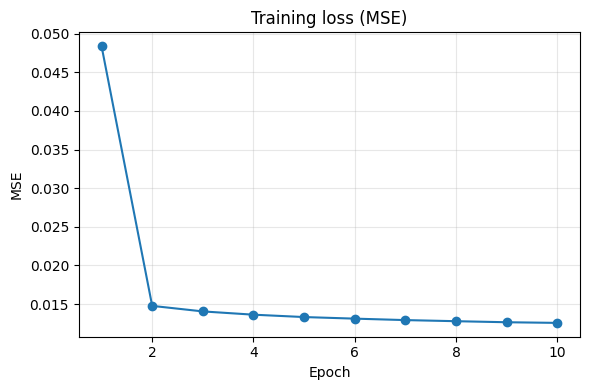

In [6]:
# Training-loss curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), history, marker="o")
plt.title("Training loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Results — denoising the test set

We pass the **noisy test images** (which the model never trained on) through the
network and compare:

- **Top row:** noisy input
- **Middle row:** model's denoised output
- **Bottom row:** original clean image (ground truth)

Test reconstruction MSE (denoised vs clean): 0.01240


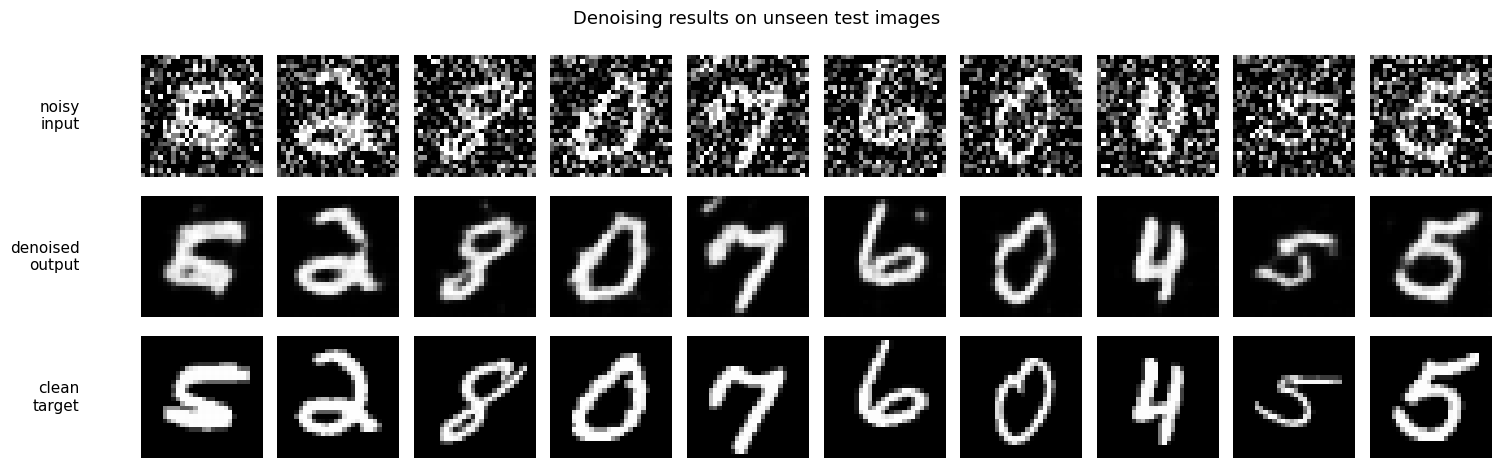

In [7]:
model.eval()
with torch.no_grad():
    denoised = model(x_test_noisy.to(device)).cpu()

# Reconstruction error on the test set
test_mse = nn.functional.mse_loss(denoised, x_test).item()
print(f"Test reconstruction MSE (denoised vs clean): {test_mse:.5f}")

n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 4.8))
for i in range(n):
    j = sample_idx[i]                                  # show a spread of digits
    axes[0, i].imshow(x_test_noisy[j, 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(denoised[j, 0],     cmap="gray"); axes[1, i].axis("off")
    axes[2, i].imshow(x_test[j, 0],       cmap="gray"); axes[2, i].axis("off")
for ax, label in zip(axes[:, 0], ["noisy\ninput", "denoised\noutput", "clean\ntarget"]):
    ax.set_title("")
    ax.text(-0.5, 0.5, label, transform=ax.transAxes, ha="right", va="center", fontsize=11)
fig.suptitle("Denoising results on unseen test images", fontsize=13)
plt.tight_layout(); plt.show()

## 6. Save the trained model

In [8]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/denoising_autoencoder.pth")
print("Saved -> models/denoising_autoencoder.pth")

Saved -> models/denoising_autoencoder.pth


## Conclusion

The convolutional denoising autoencoder learns to reconstruct clean MNIST digits
from heavily noised inputs. Even though every training image was corrupted with
fresh random noise, the encoder–decoder is forced to learn the essential
structure of each digit, so at test time it produces clean, recognisable digits
from inputs it has never seen.

**Ideas to extend this:**
- Try different `NOISE_FACTOR` values, or other noise types (salt-and-pepper).
- Add a third conv layer or batch-norm for a deeper model.
- Swap MSE for a perceptual / SSIM loss for sharper reconstructions.
- Compare against a plain (fully-connected) autoencoder baseline.